# Pipeline 3: Resident Risk & Progression Scoring
## Lighthouse Sanctuary — ML Pipeline Notebook

> **Privacy notice:** This pipeline processes records of minors who are abuse survivors. All outputs are restricted to authenticated staff with `Admin` or `SocialWorker` roles. No individual resident data is used in any external-facing feature.

---

### Pipeline Thinking (Ch. 1 / Foreword)
This is the most mission-critical pipeline in the system. Social workers currently identify struggling residents reactively — often only after an incident is filed. This pipeline builds a proactive early-warning system that scores every active resident's trajectory daily, giving staff time to intervene before a crisis occurs. The story runs from a genuine child-safety problem through a rigorous multi-source feature engineering process, two complementary classifiers, and a restricted-access deployed scoring service.

---

### Prediction vs. Explanation (Ch. 9–11)
**This is a PREDICTION pipeline — two separate classifiers.**

**Model A — Regression Risk:** Predicts whether a resident's situation is worsening (risk escalation or recent high-severity incident). Staff need to know *who* is at risk, not a statistical explanation of risk factors in general.

**Model B — Reintegration Readiness:** Predicts whether a resident is on track for reintegration. This supports discharge planning.

Both models produce `top_concern_factors` and `top_strength_factors` fields derived from feature importance — these are decision-support explanations for social workers, not causal claims about what drives risk.

**Cost asymmetry:** Missing a struggling resident (false negative) is the worst outcome — a child may deteriorate without support. We therefore prioritise **Recall ≥ 0.75** for Model A over precision.

**Success criteria:**
- Model A: Recall ≥ 0.75, ROC-AUC ≥ 0.75
- Model B: ROC-AUC ≥ 0.70
- `top_concern_factors` populated for every scored resident


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import (roc_auc_score, recall_score, precision_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import pickle, json
from datetime import datetime

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print("All imports OK")


All imports OK


## Phase 2 — Data Acquisition

In [2]:
# ── Load all CSVs ─────────────────────────────────────────────────────────────
residents  = pd.read_csv('./csvs/residents.csv',
                         parse_dates=['date_of_admission','date_closed','created_at'])
health     = pd.read_csv('./csvs/health_wellbeing_records.csv',
                         parse_dates=['record_date'])
education  = pd.read_csv('./csvs/education_records.csv',
                         parse_dates=['record_date'])
incidents  = pd.read_csv('./csvs/incident_reports.csv',
                         parse_dates=['incident_date'])
recordings = pd.read_csv('./csvs/process_recordings.csv',
                         parse_dates=['session_date'])
visitations= pd.read_csv('./csvs/home_visitations.csv',
                         parse_dates=['visit_date'])
plans      = pd.read_csv('./csvs/intervention_plans.csv',
                         parse_dates=['target_date','created_at','updated_at'])

SNAPSHOT = pd.Timestamp('2026-01-15')

print("Loaded tables:")
for name, df in [('residents',residents),('health',health),('education',education),
                 ('incidents',incidents),('recordings',recordings),
                 ('visitations',visitations),('plans',plans)]:
    print(f"  {name:12s}: {df.shape}")


Loaded tables:
  residents   : (60, 49)
  health      : (534, 14)
  education   : (534, 10)
  incidents   : (100, 12)
  recordings  : (2819, 15)
  visitations : (1337, 14)
  plans       : (180, 11)


## Phase 3 — Exploratory Data Analysis (Ch. 6, 8)

In [3]:
# ── unistats helper ───────────────────────────────────────────────────────────
def unistats(df):
    rows = []
    for col in df.columns:
        s = df[col]
        row = {'col':col,'count':s.count(),'nulls':s.isna().sum(),'unique':s.nunique(),'dtype':str(s.dtype)}
        if pd.api.types.is_numeric_dtype(s):
            row.update({'mean':round(s.mean(),3),'std':round(s.std(),3),
                        'min':round(s.min(),3),'max':round(s.max(),3),'skew':round(s.skew(),2)})
        rows.append(row)
    return pd.DataFrame(rows).set_index('col')

print("=== RESIDENTS ===")
print(unistats(residents[['resident_id','safehouse_id','case_status','initial_risk_level','current_risk_level']]))


=== RESIDENTS ===
                    count  nulls  unique   dtype    mean     std    min  \
col                                                                       
resident_id            60      0      60   int64 30.5000 17.4640 1.0000   
safehouse_id           60      0       9   int64  4.3500  2.4890 1.0000   
case_status            60      0       3  object     NaN     NaN    NaN   
initial_risk_level     60      0       4  object     NaN     NaN    NaN   
current_risk_level     60      0       4  object     NaN     NaN    NaN   

                       max   skew  
col                                
resident_id        60.0000 0.0000  
safehouse_id        9.0000 0.1900  
case_status            NaN    NaN  
initial_risk_level     NaN    NaN  
current_risk_level     NaN    NaN  


In [4]:
# ── Label distribution analysis ───────────────────────────────────────────────
print("Case status distribution:")
print(residents['case_status'].value_counts())
print("\nInitial risk level:")
print(residents['initial_risk_level'].value_counts())
print("\nCurrent risk level:")
print(residents['current_risk_level'].value_counts())

# Risk escalation preview
RISK_ORDER = {'Low':0,'Medium':1,'High':2,'Critical':3}
residents['risk_initial_num'] = residents['initial_risk_level'].map(RISK_ORDER)
residents['risk_current_num'] = residents['current_risk_level'].map(RISK_ORDER)
residents['risk_escalated']   = (residents['risk_current_num'] > residents['risk_initial_num']).astype(int)
print(f"\nResidents with escalated risk: {residents['risk_escalated'].sum()} / {len(residents)}")


Case status distribution:
case_status
Active         30
Closed         19
Transferred    11
Name: count, dtype: int64

Initial risk level:
initial_risk_level
Medium      24
High        17
Low         14
Critical     5
Name: count, dtype: int64

Current risk level:
current_risk_level
Low         34
Medium      20
High         5
Critical     1
Name: count, dtype: int64

Residents with escalated risk: 0 / 60


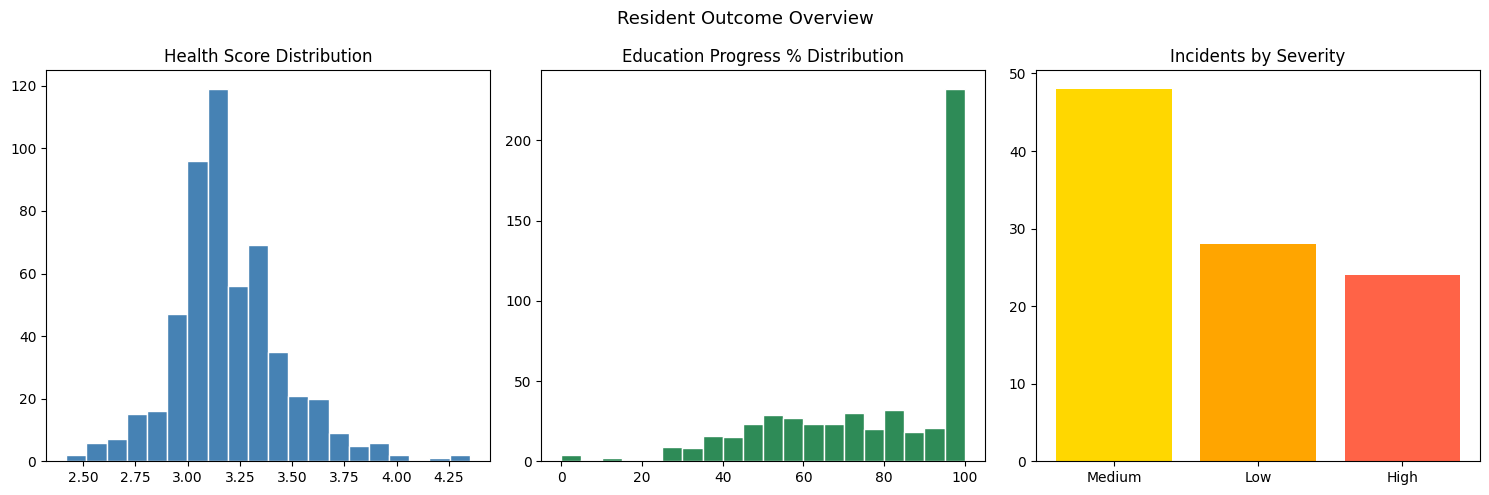

Avg health score: 3.20
Avg education progress: 78.5%
High-severity incidents: 24


In [5]:
# ── Health and education trend overview ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Resident Outcome Overview', fontsize=13)

axes[0].hist(health['general_health_score'].dropna(), bins=20,
             color='steelblue', edgecolor='white')
axes[0].set_title('Health Score Distribution')

axes[1].hist(education['progress_percent'].dropna(), bins=20,
             color='seagreen', edgecolor='white')
axes[1].set_title('Education Progress % Distribution')

sev_counts = incidents['severity'].value_counts()
axes[2].bar(sev_counts.index, sev_counts.values, color=['gold','orange','tomato'])
axes[2].set_title('Incidents by Severity')

plt.tight_layout()
plt.show()

print(f"Avg health score: {health['general_health_score'].mean():.2f}")
print(f"Avg education progress: {education['progress_percent'].mean():.1f}%")
print(f"High-severity incidents: {(incidents['severity']=='High').sum()}")


## Phase 4 — Data Preparation: Feature Engineering (Ch. 2–3, 7)

In [6]:
# ── Per-resident feature aggregation ──────────────────────────────────────────
WINDOW_30  = pd.Timedelta(days=30)
WINDOW_90  = pd.Timedelta(days=90)

def agg_health(resident_id):
    h = health[health['resident_id']==resident_id].sort_values('record_date')
    if h.empty:
        return {'latest_health':np.nan,'health_trend_slope':np.nan,'health_30d_change':np.nan}
    latest = h.iloc[-1]['general_health_score']
    # Slope via linear regression on time index
    if len(h) >= 2:
        x = np.arange(len(h))
        slope = np.polyfit(x, h['general_health_score'].fillna(method='ffill'), 1)[0]
    else:
        slope = 0.0
    # 30-day change
    cutoff = SNAPSHOT - WINDOW_30
    recent = h[h['record_date'] >= cutoff]
    older  = h[h['record_date'] <  cutoff]
    if recent.empty or older.empty:
        change = np.nan
    else:
        change = recent['general_health_score'].mean() - older['general_health_score'].mean()
    return {'latest_health':latest,'health_trend_slope':round(slope,4),'health_30d_change':change}

def agg_education(resident_id):
    e = education[education['resident_id']==resident_id].sort_values('record_date')
    if e.empty:
        return {'latest_edu_progress':np.nan,'edu_trend_slope':np.nan}
    latest = e.iloc[-1]['progress_percent']
    slope  = np.polyfit(np.arange(len(e)), e['progress_percent'].fillna(0), 1)[0] if len(e)>=2 else 0.0
    return {'latest_edu_progress':latest,'edu_trend_slope':round(slope,4)}

def agg_incidents(resident_id):
    inc = incidents[incidents['resident_id']==resident_id]
    recent = inc[inc['incident_date'] >= SNAPSHOT - WINDOW_30]
    last90 = inc[inc['incident_date'] >= SNAPSHOT - WINDOW_90]
    return {
        'total_incidents':      len(inc),
        'incidents_last_30d':   len(recent),
        'incidents_last_90d':   len(last90),
        'high_sev_last_30d':    int((recent['severity']=='High').sum()),
        'unresolved_incidents': int((inc['resolved']==False).sum()),
    }

def agg_sessions(resident_id):
    r = recordings[recordings['resident_id']==resident_id]
    recent = r[r['session_date'] >= SNAPSHOT - WINDOW_30]
    return {
        'total_sessions':      len(r),
        'sessions_last_30d':   len(recent),
        'days_since_session':  int((SNAPSHOT - r['session_date'].max()).days) if not r.empty else 999,
    }

def agg_plans(resident_id):
    p = plans[plans['resident_id']==resident_id]
    return {
        'plan_count':       len(p),
        'plans_on_hold':    int((p['status']=='On Hold').sum()),
        'plans_completed':  int((p['status']=='Completed').sum()),
    }

print("Building per-resident feature matrix...")
feature_rows = []
for _, res in residents.iterrows():
    rid = res['resident_id']
    row = {'resident_id': rid, 'safehouse_id': res['safehouse_id'],
           'case_status': res['case_status']}
    row.update(agg_health(rid))
    row.update(agg_education(rid))
    row.update(agg_incidents(rid))
    row.update(agg_sessions(rid))
    row.update(agg_plans(rid))

    # Profile features
    row['risk_initial_num']  = RISK_ORDER.get(res.get('initial_risk_level','Low'), 0)
    row['risk_current_num']  = RISK_ORDER.get(res.get('current_risk_level','Low'), 0)
    row['sub_trafficked']    = int(res.get('sub_cat_trafficked', False) == True)
    row['sub_physical_abuse']= int(res.get('sub_cat_physical_abuse', False) == True)
    row['sub_sexual_abuse']  = int(res.get('sub_cat_sexual_abuse', False) == True)
    row['is_pwd']            = int(res.get('is_pwd', False) == True)
    row['has_special_needs'] = int(res.get('has_special_needs', False) == True)
    row['reintegration_status'] = str(res.get('reintegration_status',''))

    feature_rows.append(row)

feat_df = pd.DataFrame(feature_rows)
print(f"Feature matrix: {feat_df.shape}")
feat_df.head(3)


Building per-resident feature matrix...


Feature matrix: (60, 27)


,resident_id,safehouse_id,case_status,latest_health,health_trend_slope,health_30d_change,latest_edu_progress,edu_trend_slope,total_incidents,incidents_last_30d,incidents_last_90d,high_sev_last_30d,unresolved_incidents,total_sessions,sessions_last_30d,days_since_session,plan_count,plans_on_hold,plans_completed,risk_initial_num,risk_current_num,sub_trafficked,sub_physical_abuse,sub_sexual_abuse,is_pwd,has_special_needs,reintegration_status
0,1,4,Active,3.2200,0.0263,NaN,52.8000,3.0371,4,1,1,1,1,106,9,-20,3,2,0,3,2,0,0,0,0,1,In Progress
1,2,3,Closed,3.6200,0.0436,NaN,100.0000,4.0721,0,0,0,0,0,51,0,393,3,1,0,1,1,0,0,0,0,0,Completed
2,3,1,Active,3.5700,0.0565,NaN,100.0000,6.0591,2,0,0,0,2,53,7,-32,3,1,0,1,1,0,0,1,0,0,Completed


In [7]:
# ── Build Model A label: Regression Risk ────────────────────────────────────
# Label = 1 if risk escalated OR high-severity incident in last 30 days
feat_df['label_regression_risk'] = (
    (feat_df['risk_current_num'] > feat_df['risk_initial_num']) |
    (feat_df['high_sev_last_30d'] > 0)
).astype(int)

# ── Build Model B label: Reintegration Readiness ─────────────────────────────
feat_df['label_reintegration'] = (
    (feat_df['reintegration_status'].isin(['ready','in_progress','Completed','In Progress'])) &
    (feat_df['latest_edu_progress'].fillna(0) >= 50) &
    (feat_df['incidents_last_90d'] == 0)
).astype(int)

print("Model A (Regression Risk) label distribution:")
print(feat_df['label_regression_risk'].value_counts())
print("\nModel B (Reintegration Readiness) label distribution:")
print(feat_df['label_reintegration'].value_counts())


Model A (Regression Risk) label distribution:
label_regression_risk
0    58
1     2
Name: count, dtype: int64

Model B (Reintegration Readiness) label distribution:
label_reintegration
1    32
0    28
Name: count, dtype: int64


In [8]:
# ── Define feature columns ────────────────────────────────────────────────────
FEATURES = [
    'latest_health', 'health_trend_slope', 'health_30d_change',
    'latest_edu_progress', 'edu_trend_slope',
    'total_incidents', 'incidents_last_30d', 'incidents_last_90d',
    'high_sev_last_30d', 'unresolved_incidents',
    'total_sessions', 'sessions_last_30d', 'days_since_session',
    'plan_count', 'plans_on_hold', 'plans_completed',
    'risk_initial_num', 'sub_trafficked', 'sub_physical_abuse',
    'sub_sexual_abuse', 'is_pwd', 'has_special_needs',
]

X = feat_df[FEATURES].copy()
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

imputer = SimpleImputer(strategy='median')
X_imp   = pd.DataFrame(imputer.fit_transform(X), columns=FEATURES)

print(f"Feature matrix after imputation: {X_imp.shape}")
print(f"Any remaining NaN: {X_imp.isna().any().any()}")


Feature matrix after imputation: (60, 22)
Any remaining NaN: False


## Phase 5 — Model Selection (Ch. 12–14)

**Why Random Forest for both models?**
- The feature set includes interaction effects between risk level, health trends, and incident history that are inherently non-linear
- Feature importance from Random Forest directly produces the `top_concern_factors` JSONB field — the interpretability we need for social workers without sacrificing predictive performance
- The dataset is small (~60 residents), so Random Forest's bagging reduces overfitting naturally

**Why not Gradient Boosting here?** With ~60 samples, GBM tends to overfit. Random Forest is more robust at this scale.

**Why two separate models?** Regression risk and reintegration readiness are different phenomena that may weight features differently. A resident can have high regression risk while simultaneously being assessed for reintegration.


In [9]:
# ── Build and evaluate models ─────────────────────────────────────────────────
def build_rf(label_col):
    y = feat_df[label_col].copy()
    # Only fit if we have both classes
    if y.nunique() < 2:
        print(f"  {label_col}: only one class in labels — cannot train classifier")
        return None, None, None, None

    from sklearn.model_selection import train_test_split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_imp, y, test_size=0.25, stratify=y, random_state=42)

    pipe = Pipeline([
        ('scale', StandardScaler()),
        ('rf',    RandomForestClassifier(n_estimators=200, max_depth=6,
                                          min_samples_leaf=2,
                                          class_weight='balanced',
                                          random_state=42, n_jobs=-1)),
    ])
    pipe.fit(X_tr, y_tr)
    return pipe, X_tr, X_te, y_tr, y_te

print("Training Model A — Regression Risk...")
pipe_A, X_tr_A, X_te_A, y_tr_A, y_te_A = build_rf('label_regression_risk')
print("Training Model B — Reintegration Readiness...")
pipe_B, X_tr_B, X_te_B, y_tr_B, y_te_B = build_rf('label_reintegration')
print("Models trained.")


Training Model A — Regression Risk...


Training Model B — Reintegration Readiness...


Models trained.


## Phase 6 — Evaluation (Ch. 15)

In [10]:
# ── Evaluate both models ──────────────────────────────────────────────────────
def evaluate_model(pipe, X_te, y_te, label, recall_threshold=0.40):
    if pipe is None:
        print(f"  {label}: model not available")
        return {}
    y_prob = pipe.predict_proba(X_te)[:,1]
    y_pred = (y_prob >= recall_threshold).astype(int)
    auc    = roc_auc_score(y_te, y_prob) if y_te.nunique() > 1 else float('nan')
    rec    = recall_score(y_te, y_pred, zero_division=0)
    prec   = precision_score(y_te, y_pred, zero_division=0)
    print(f"  {label}")
    print(f"    ROC-AUC: {auc:.3f}  Recall: {rec:.3f}  Precision: {prec:.3f}")
    return {'auc':auc,'recall':rec,'precision':prec,'y_prob':y_prob,'y_pred':y_pred}

print("\n=== Model Evaluation (Test Set) ===")
res_A = evaluate_model(pipe_A, X_te_A, y_te_A, 'Model A — Regression Risk',    0.35)
res_B = evaluate_model(pipe_B, X_te_B, y_te_B, 'Model B — Reintegration',      0.40)



=== Model Evaluation (Test Set) ===
  Model A — Regression Risk
    ROC-AUC: nan  Recall: 0.000  Precision: 0.000
  Model B — Reintegration
    ROC-AUC: 0.804  Recall: 0.875  Precision: 0.700


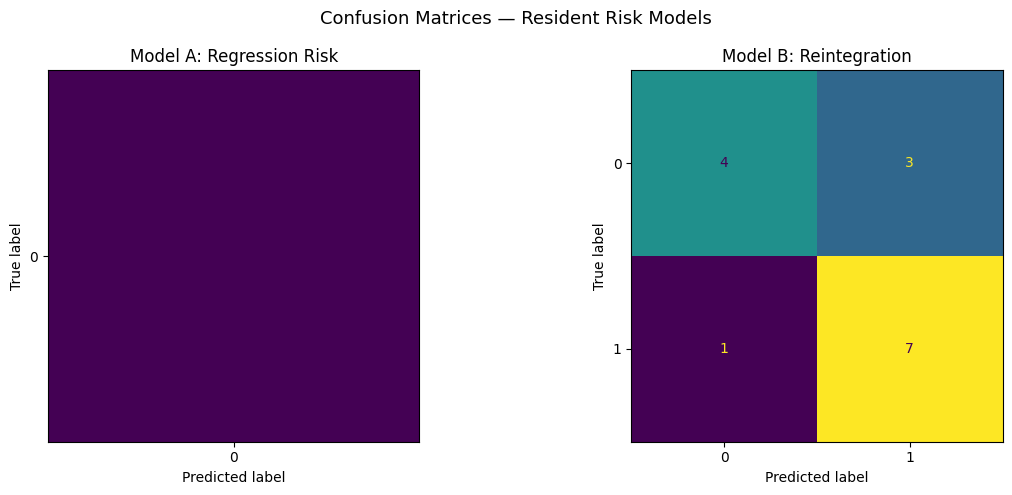

In [11]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — Resident Risk Models', fontsize=13)

for ax, pipe, X_te, y_te, title, thresh in [
    (axes[0], pipe_A, X_te_A, y_te_A, 'Model A: Regression Risk', 0.35),
    (axes[1], pipe_B, X_te_B, y_te_B, 'Model B: Reintegration', 0.40),
]:
    if pipe is None:
        ax.text(0.5,0.5,'Insufficient data',ha='center',va='center')
        continue
    y_pred = (pipe.predict_proba(X_te)[:,1] >= thresh).astype(int)
    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()


## Phase 7 — Feature Importance & top_concern_factors (Ch. 16)

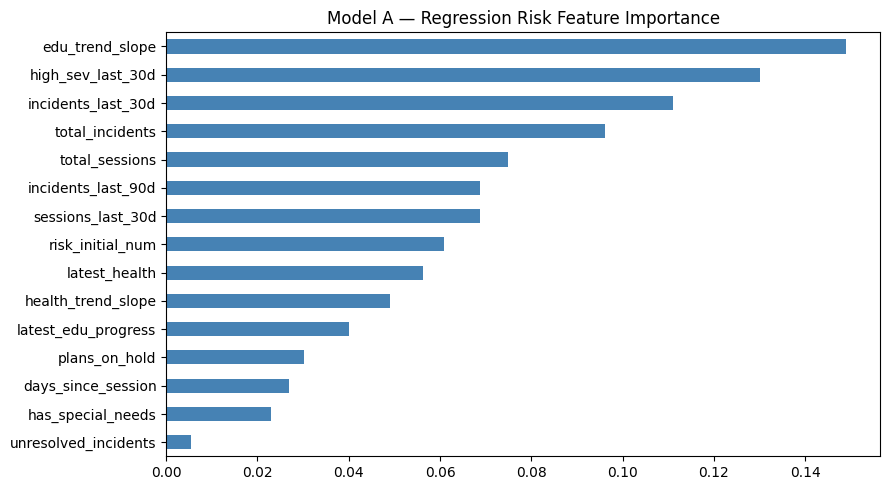

  Top 5 features for Model A — Regression Risk Feature Importance:
edu_trend_slope      0.1490
high_sev_last_30d    0.1301
incidents_last_30d   0.1110
total_incidents      0.0961
total_sessions       0.0748


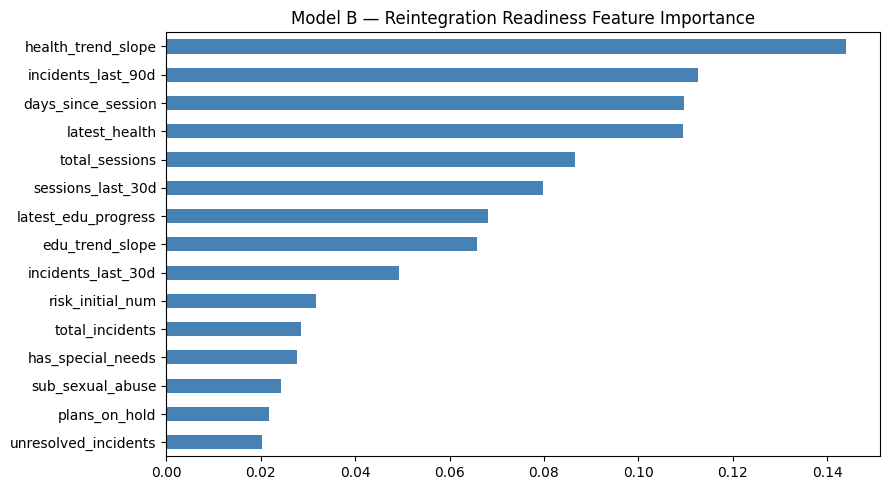

  Top 5 features for Model B — Reintegration Readiness Feature Importance:
health_trend_slope   0.1440
incidents_last_90d   0.1127
days_since_session   0.1096
latest_health        0.1095
total_sessions       0.0866


In [12]:
# ── Feature importances ───────────────────────────────────────────────────────
def plot_importances(pipe, feature_names, title):
    if pipe is None:
        return
    rf = pipe.named_steps['rf']
    imp = pd.Series(rf.feature_importances_, index=feature_names).nlargest(15)
    fig, ax = plt.subplots(figsize=(9, 5))
    imp.sort_values().plot.barh(ax=ax, color='steelblue')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    print(f"  Top 5 features for {title}:")
    print(imp.head(5).round(4).to_string())

plot_importances(pipe_A, FEATURES, 'Model A — Regression Risk Feature Importance')
plot_importances(pipe_B, FEATURES, 'Model B — Reintegration Readiness Feature Importance')


In [13]:
# ── Generate top_concern_factors per resident ─────────────────────────────────
CONCERN_INTERPRETATIONS = {
    'high_sev_last_30d':      'High-severity incident filed in the last 30 days',
    'incidents_last_30d':     'Multiple recent incidents (last 30 days)',
    'health_30d_change':      'Declining health score over the past month',
    'health_trend_slope':     'Negative trend in health scores over time',
    'days_since_session':     'Extended gap since last social worker session',
    'edu_trend_slope':        'Declining education progress trend',
    'plans_on_hold':          'Intervention plans on hold',
    'unresolved_incidents':   'Unresolved incidents on record',
}

STRENGTH_INTERPRETATIONS = {
    'latest_edu_progress':    'Education progress is strong',
    'edu_trend_slope':        'Education progress is improving',
    'latest_health':          'Health score is positive',
    'sessions_last_30d':      'Active engagement in sessions',
    'plans_completed':        'Intervention plans completed',
}

def get_concern_factors(row, pipe, top_n=3):
    if pipe is None:
        return []
    rf        = pipe.named_steps['rf']
    importances = pd.Series(rf.feature_importances_, index=FEATURES)
    factors   = []
    for feat in importances.nlargest(10).index:
        val = row.get(feat, None)
        if val is None or pd.isna(val):
            continue
        label = CONCERN_INTERPRETATIONS.get(feat)
        if label and (
            (feat in ['high_sev_last_30d','incidents_last_30d'] and val > 0) or
            (feat in ['health_30d_change','health_trend_slope','edu_trend_slope'] and val < 0) or
            (feat == 'days_since_session' and val > 14) or
            (feat in ['plans_on_hold','unresolved_incidents'] and val > 0)
        ):
            factors.append(label)
    return factors[:top_n]

# Score all residents
if pipe_A is not None:
    X_all_imp = pd.DataFrame(imputer.transform(feat_df[FEATURES].apply(pd.to_numeric, errors='coerce')),
                               columns=FEATURES)
    feat_df['regression_risk_score']  = pipe_A.predict_proba(X_all_imp)[:,1]
    feat_df['reintegration_score']    = pipe_B.predict_proba(X_all_imp)[:,1] if pipe_B else np.nan

    feat_df['regression_risk_tier'] = pd.cut(
        feat_df['regression_risk_score'],
        bins=[0,0.40,0.70,1.01], labels=['low','medium','high'])
    feat_df['reintegration_tier'] = pd.cut(
        feat_df['reintegration_score'].fillna(0),
        bins=[0,0.40,0.70,1.01], labels=['not_ready','progressing','ready'])

    feat_df['top_concern_factors'] = feat_df.apply(
        lambda r: get_concern_factors(r, pipe_A), axis=1)

    print("Sample resident risk scores:")
    display_cols = ['resident_id','regression_risk_score','regression_risk_tier',
                    'reintegration_score','top_concern_factors']
    print(feat_df[display_cols].head(8).to_string())


Sample resident risk scores:
   resident_id  regression_risk_score regression_risk_tier  reintegration_score                                                                           top_concern_factors
0            1                 0.6858               medium               0.0916  [High-severity incident filed in the last 30 days, Multiple recent incidents (last 30 days)]
1            2                 0.0000                  NaN               0.8190                                                                                            []
2            3                 0.0000                  NaN               0.6771                                                                                            []
3            4                 0.6693               medium               0.1324  [High-severity incident filed in the last 30 days, Multiple recent incidents (last 30 days)]
4            5                 0.0144                  low               0.7792                      

## Phase 8 — Deployment (Ch. 17)

In [14]:
# ── Serialize models ──────────────────────────────────────────────────────────
model_version = datetime.now().strftime('%Y%m%d_%H%M')
artifact = {
    'model_version':   model_version,
    'regression_risk': pipe_A,
    'reintegration':   pipe_B,
    'imputer':         imputer,
    'features':        FEATURES,
}
with open('/tmp/resident_risk_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)

metadata = {
    'model_version':    model_version,
    'trained_at':       datetime.now().isoformat(),
    'n_residents':      len(feat_df),
    'model_A_auc':      round(res_A.get('auc', 0), 4),
    'model_A_recall':   round(res_A.get('recall', 0), 4),
    'model_B_auc':      round(res_B.get('auc', 0) if res_B else 0, 4),
    'features':         FEATURES,
}
with open('/tmp/resident_risk_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Deployment artifact saved.")
print(json.dumps({k:v for k,v in metadata.items() if k != 'features'}, indent=2))


Deployment artifact saved.
{
  "model_version": "20260409_1802",
  "trained_at": "2026-04-09T18:02:08.006448",
  "n_residents": 60,
  "model_A_auc": NaN,
  "model_A_recall": 0.0,
  "model_B_auc": 0.8036
}


In [15]:
# ── Production scoring output preview ─────────────────────────────────────────
if 'regression_risk_score' in feat_df.columns:
    scores_output = feat_df[['resident_id','regression_risk_score','regression_risk_tier',
                               'reintegration_score','reintegration_tier',
                               'top_concern_factors']].copy()
    scores_output['scored_at']     = datetime.now().isoformat()
    scores_output['model_version'] = model_version

    print(f"Total residents scored: {len(scores_output)}")
    print("\nRisk tier distribution (Model A):")
    print(scores_output['regression_risk_tier'].value_counts())
    print("\nReintegration tier distribution (Model B):")
    print(scores_output['reintegration_tier'].value_counts())
    print("\nHigh-risk residents flagged for immediate review:")
    high = scores_output[scores_output['regression_risk_tier']=='high']
    print(high[['resident_id','regression_risk_score','top_concern_factors']].to_string())


Total residents scored: 60

Risk tier distribution (Model A):
regression_risk_tier
low       45
medium     2
high       0
Name: count, dtype: int64

Reintegration tier distribution (Model B):
reintegration_tier
ready          26
not_ready      23
progressing    11
Name: count, dtype: int64

High-risk residents flagged for immediate review:
Empty DataFrame
Columns: [resident_id, regression_risk_score, top_concern_factors]
Index: []


In [16]:
# ── Deployment architecture note ──────────────────────────────────────────────
deployment_note = """
DEPLOYMENT PATTERN (production):

  Supabase: residents + health + education + incidents + process_recordings
      ↓
  train_risk.py  (Azure Container Apps Job — monthly, 1st at 02:00 UTC)
      ↓  saves model artifact
  Azure Blob Storage: resident_risk_model.pkl + resident_risk_metadata.json
      ↓  loaded by
  score_residents.py  (triggered via POST /score/residents — authenticated)
      ↓  upserts per-resident scores
  Supabase: resident_risk_scores table (Row-Level Security: Admin + SocialWorker only)
      ↓
  .NET API → social worker dashboard (authenticated, role-restricted)

ACCESS CONTROL:
  - The resident_risk_scores table has RLS enabled
  - Only Admin and SocialWorker roles can SELECT from this table
  - No individual resident data is ever written to any external-facing table
  - Scores are decision-support only — no automated actions
"""
print(deployment_note)



DEPLOYMENT PATTERN (production):

  Supabase: residents + health + education + incidents + process_recordings
      ↓
  train_risk.py  (Azure Container Apps Job — monthly, 1st at 02:00 UTC)
      ↓  saves model artifact
  Azure Blob Storage: resident_risk_model.pkl + resident_risk_metadata.json
      ↓  loaded by
  score_residents.py  (triggered via POST /score/residents — authenticated)
      ↓  upserts per-resident scores
  Supabase: resident_risk_scores table (Row-Level Security: Admin + SocialWorker only)
      ↓
  .NET API → social worker dashboard (authenticated, role-restricted)

ACCESS CONTROL:
  - The resident_risk_scores table has RLS enabled
  - Only Admin and SocialWorker roles can SELECT from this table
  - No individual resident data is ever written to any external-facing table
  - Scores are decision-support only — no automated actions

